In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import math

from common import (
    CASE_NAMES,
    INDEX_ORDER as _BASE_INDEX_ORDER,
    index_colors as _base_index_colors,
    index_markers as _base_index_markers,
    transform_duckdb_index_name,
    apply_style,
    save_fig,
    qps_median_ci,
    format_dataset_title,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)

# Toggle to show/hide point ID annotations on scatter plots.
ANNOTATE_POINT_IDS = False

# Toggle to show/hide the normal Global IVF systems (not the 256/cl variants).
SHOW_NORMAL_GLOBAL = False

# ---------------------------------------------------------------------------
# Global IVF approach split: distinguish "pgvector recommendation" (commit
# cbed8a5, lists=sqrt(n)) from "256 embeddings/cluster" (commit 9b47764,
# lists=ceil(n/256)) for PDXearch global.
# ---------------------------------------------------------------------------
_COMMIT_256_PER_CLUSTER = "9b47764"

_GLOBAL_256_F32 = "DuckDB PDXearch (IVF, Global 256/cl, F32)"
_GLOBAL_256_U8  = "DuckDB PDXearch (IVF, Global 256/cl, U8)"

try:
    _cmap = plt.colormaps["tab20"]
except (AttributeError, KeyError):
    _cmap = plt.cm.get_cmap("tab20")

# Build local INDEX_ORDER with the 256/cluster variants inserted after
# the corresponding global entries.
INDEX_ORDER = []
for idx in _BASE_INDEX_ORDER:
    INDEX_ORDER.append(idx)
    if idx == "DuckDB PDXearch (IVF, Global, F32)":
        INDEX_ORDER.append(_GLOBAL_256_F32)
    elif idx == "DuckDB PDXearch (IVF, Global, U8)":
        INDEX_ORDER.append(_GLOBAL_256_U8)

if not SHOW_NORMAL_GLOBAL:
    _NORMAL_GLOBAL = {
        "DuckDB PDXearch (IVF, Global, F32)",
        "DuckDB PDXearch (IVF, Global, U8)",
    }
    INDEX_ORDER = [idx for idx in INDEX_ORDER if idx not in _NORMAL_GLOBAL]

index_colors = dict(_base_index_colors)
index_colors[_GLOBAL_256_F32] = _cmap(4)
index_colors[_GLOBAL_256_U8]  = _cmap(5)

index_markers = dict(_base_index_markers)
index_markers[_GLOBAL_256_F32] = "h"   # hexagon — distinct from Diamond (D)
index_markers[_GLOBAL_256_U8]  = "H"


def _local_transform_index_name(db_case_cfg: dict, db_label: dict) -> str:
    """Like transform_duckdb_index_name but splits Global by commit hash."""
    global_version = db_label.get("global_version", None)
    base = transform_duckdb_index_name(db_case_cfg, global_version)
    # Only remap Global entries that came from the 256/cluster commit.
    if global_version is not None and db_label.get("pdxearch") == _COMMIT_256_PER_CLUSTER:
        base = base.replace("(IVF, Global,", "(IVF, Global 256/cl,")
    return base


def compute_qps(metrics: dict) -> tuple[float, float, float]:
    """Compute (median_qps, lo_err, hi_err) from serial_latencies via bootstrap."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return qps_median_ci(latencies)


# ---------------------------------------------------------------------------
# 1. Load Cohere6M (case_id=504) result JSONs from blob directory
# ---------------------------------------------------------------------------
COHERE6M_CASE_ID = 504

records = []


def _process_duckdb_entry(entry):
    """Process one DuckDB result entry for Cohere6M and append to records."""
    metrics = entry["metrics"]
    task_cfg = entry["task_config"]
    db_cfg = task_cfg["db_config"]
    db_case_cfg = task_cfg["db_case_config"]
    case_cfg = task_cfg["case_config"]

    if case_cfg["case_id"] != COHERE6M_CASE_ID:
        return

    db_label = json.loads(db_cfg.get("db_label", "{}"))
    index_name = _local_transform_index_name(db_case_cfg, db_label)

    _qps = compute_qps(metrics)

    records.append({
        "recall": metrics["recall"],
        "serial_qps": _qps[0],
        "serial_qps_lo": _qps[1],
        "serial_qps_hi": _qps[2],
        "index": index_name,
        "db_type": "DuckDB",
        "threads": db_cfg.get("duckdb_threads", 1),
        "source_file": str(path),
    })


duckdb_blob_results_dir = pathlib.Path("../experiments/results/index_search_blob/DuckDB")
duckdb_blob_json_files = sorted(
    p for p in duckdb_blob_results_dir.glob("*.json") if not p.name.startswith("muted_")
) if duckdb_blob_results_dir.exists() else []

for path in duckdb_blob_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        _process_duckdb_entry(entry)

print(f"Loaded {len(records)} Cohere6M results from {len(duckdb_blob_json_files)} DuckDB (blob) files")
records[:3]

Loaded 180 Cohere6M results from 865 DuckDB (blob) files


[{'recall': 0.4166,
  'serial_qps': 198.43894038765245,
  'serial_qps_lo': 8.36326749076099,
  'serial_qps_hi': 10.243998019365335,
  'index': 'DuckDB PDXearch (IVF, Global, F32)',
  'db_type': 'DuckDB',
  'threads': 1,
  'source_file': '../experiments/results/index_search_blob/DuckDB/result_20260403_duckdbpdxearch_Performance768D6M_22-31-41_duckdb.json'},
 {'recall': 0.5551,
  'serial_qps': 164.40325850546424,
  'serial_qps_lo': 9.316409870228512,
  'serial_qps_hi': 9.414054687617522,
  'index': 'DuckDB PDXearch (IVF, Global, F32)',
  'db_type': 'DuckDB',
  'threads': 1,
  'source_file': '../experiments/results/index_search_blob/DuckDB/result_20260403_duckdbpdxearch_Performance768D6M_22-39-20_duckdb.json'},
 {'recall': 0.6548,
  'serial_qps': 135.58173036183373,
  'serial_qps_lo': 13.29779337101769,
  'serial_qps_hi': 11.742493423662182,
  'index': 'DuckDB PDXearch (IVF, Global, F32)',
  'db_type': 'DuckDB',
  'threads': 1,
  'source_file': '../experiments/results/index_search_blob/Du

In [2]:
# ---------------------------------------------------------------------------
# 2. Assign point IDs
# ---------------------------------------------------------------------------

for i, r in enumerate(records):
    r["point_id"] = i

if ANNOTATE_POINT_IDS:
    print(f"{'ID':>4}  {'Recall':>7}  {'QPS':>8}  {'T':>2}  {'Index':45s}  {'File'}")
    print("-" * 140)
    for r in records:
        src = pathlib.Path(r["source_file"]).name
        print(f"{r['point_id']:>4}  {r['recall']:>7.4f}  {r['serial_qps']:>8.1f}  "
              f"{r['threads']:>2}  {r['index']:45s}  {src}")
else:
    print("Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.")

Point IDs disabled. Set ANNOTATE_POINT_IDS = True in the first cell to enable.


Index types: ['DuckDB PDXearch (IVF, Global 256/cl, F32)', 'DuckDB PDXearch (IVF, Global 256/cl, U8)', 'DuckDB PDXearch (IVF, Row Group, F32)', 'DuckDB PDXearch (IVF, Row Group, U8)']
  1 Thread: 90 records
  14 Threads: 90 records


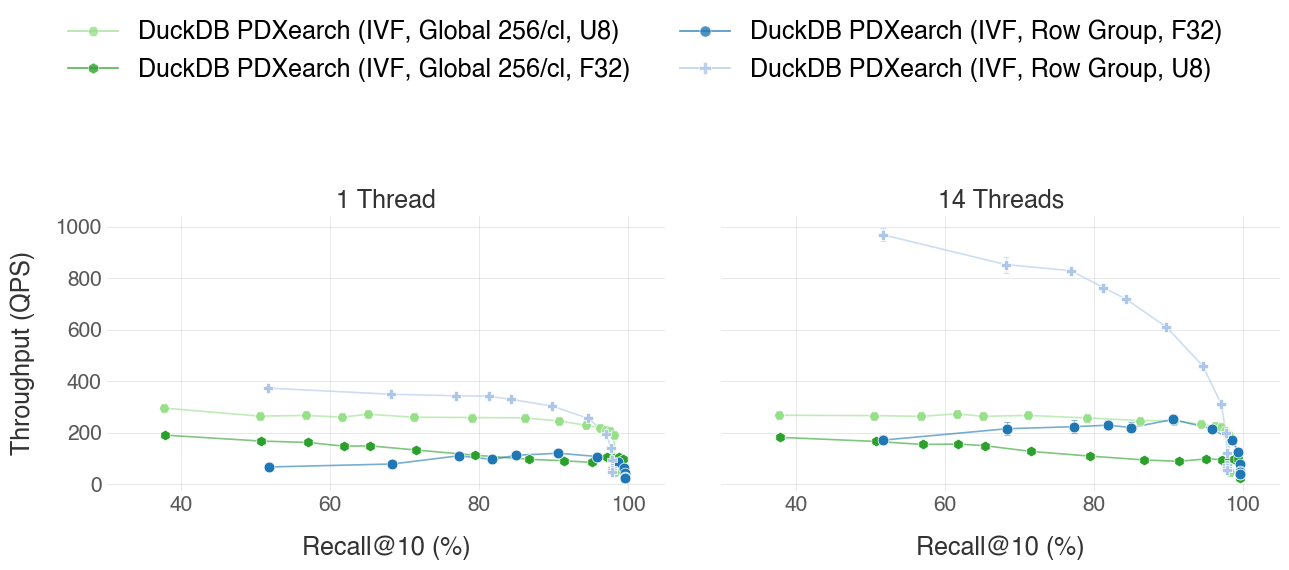

In [3]:
# ---------------------------------------------------------------------------
# 3. Combined side-by-side: 1 thread (left) vs 14 threads (right)
#    Single row for Cohere6M, with Global IVF approach distinction.
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

DATASET_NAME = CASE_NAMES[COHERE6M_CASE_ID]

thread_groups = [
    ("1 Thread", [r for r in records if r["threads"] == 1]),
    ("14 Threads", [r for r in records if r["threads"] > 1]),
]

# Build grouped data for each thread group
grouped_by_thread: list[dict[str, list]] = []
all_index_types = set()
for _, recs in thread_groups:
    g: dict[str, list] = defaultdict(list)
    for r in recs:
        g[r["index"]].append(
            (r["recall"], r["serial_qps"], r["serial_qps_lo"], r["serial_qps_hi"], r.get("point_id", -1))
        )
    grouped_by_thread.append(g)
    all_index_types.update(g.keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

print(f"Index types: {all_index_types}")
for label, recs in thread_groups:
    print(f"  {label}: {len(recs)} records")

# Plot
n_cols = len(thread_groups)
fig, axes = plt.subplots(1, n_cols, figsize=(6.5 * n_cols, 5.5), squeeze=False, sharey=True)

for col_idx, (col_title, _) in enumerate(thread_groups):
    ax = axes[0][col_idx]
    grouped = grouped_by_thread[col_idx]

    for index_type in all_index_types:
        points = grouped.get(index_type, [])
        if not points:
            continue
        points.sort(key=lambda p: p[0])
        recalls = [p[0] for p in points]
        qps_vals = [p[1] for p in points]
        qps_lo = [p[2] for p in points]
        qps_hi = [p[3] for p in points]
        point_ids = [p[4] for p in points]

        color = index_colors.get(index_type, "#808080")
        marker = index_markers.get(index_type, "o")

        ax.errorbar(recalls, qps_vals, yerr=[qps_lo, qps_hi], fmt="none",
                   ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, alpha=0.5, zorder=3)
        ms = MARKER_SIZE * 2.5 if index_type == "DuckDB" else MARKER_SIZE
        ax.scatter(recalls, qps_vals, color=color, marker=marker, s=ms,
                   zorder=3, edgecolors="white", linewidths=0.5)
        ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)
        if ANNOTATE_POINT_IDS:
            for _r, _q, _pid in zip(recalls, qps_vals, point_ids):
                ax.annotate(str(_pid), (_r, _q), fontsize=5, ha="left", va="bottom",
                            color="#333333", xytext=(3, 3), textcoords="offset points", zorder=10)

    ax.set_title(col_title, fontsize=TITLE_FONTSIZE, color=FONT_COLOR)
    ax.set_xlabel("Recall@10 (%)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)
    if col_idx == 0:
        ax.set_ylabel("Throughput (QPS)", fontsize=LABEL_FONTSIZE, color=FONT_COLOR, labelpad=15)

    ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([i / 5 for i in range(6)])
    ax.set_xlim(0.30, 1.05)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.0f}"))

    ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

# Legend
legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))
# Reorder legend
if SHOW_NORMAL_GLOBAL:
    (legend_handles[1], legend_handles[2]) = (legend_handles[2], legend_handles[1])
else:
    (legend_handles[1], legend_handles[0]) = (legend_handles[0], legend_handles[1])

fig.legend(handles=legend_handles, loc="upper center",
           ncol=math.ceil(len(all_index_types) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.08))

fig.tight_layout(rect=[0, 0.03, 1, 0.76])
fig.subplots_adjust(wspace=0.10)
save_fig("index_search_cohere6m_blob")
plt.show()